# Cardiovascular Disease Prediction

This notebook serves as the **central hub** for the cardiovascular disease prediction project. It imports and orchestrates modularized Python scripts from `src/` to maintain clean architecture and code reusability.

## Project Structure

```
src/
├── data/
│   └── explore.py         # Data exploration and analysis
├── features/
│   └── build_features.py  # Data cleaning and feature engineering
└── models/
    ├── train.py           # Model training functions
    └── predict.py         # Model prediction functions
```

Each module can be **executed independently** as a standalone script using Python.

## 1. Setup & Imports

Import all necessary libraries and modules from `src/`

In [ ]:
import sys
import pandas as pd
import numpy as np
import os
import warnings
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
sys.path.append('./')
from src.features.build_features import clean_data, split_and_scale
from src.models.train import (
    train_logistic_regression,
    train_naive_bayes,
    train_decision_tree,
    train_linear_svm,
    evaluate_model
)
from src.models.predict import load_model, predict_single_instance

## 2. Data Exploration

Load and explore the raw cardiovascular disease dataset

In [37]:
# Load raw data
df = pd.read_csv('data/raw/cardio_train.csv', sep=';')
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFirst few rows:")
print(df.head())

Shape: 70000 rows, 13 columns

Column names and types:
id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

First few rows:
   id    age  gender  height  weight  ap_hi  ap_lo  cholesterol  gluc  smoke  \
0   0  18393       2     168    62.0    110     80            1     1      0   
1   1  20228       1     156    85.0    140     90            3     1      0   
2   2  18857       1     165    64.0    130     70            3     1      0   
3   3  17623       2     169    82.0    150    100            1     1      0   
4   4  17474       1     156    56.0    100     60            1     1      0   

   alco  active  cardio  
0     0       1       0  
1     0       1       1  
2     0       0       1  
3     0       1       1  
4   

## 3. Data Cleaning & Feature Engineering

Using `src/features/build_features.py` to clean data and prepare features

In [38]:
df_cleaned = clean_data(df)
print(f"\nOriginal dataset: {df.shape[0]} rows")
print(f"Cleaned dataset:  {df_cleaned.shape[0]} rows")
print(f"Rows removed:     {df.shape[0] - df_cleaned.shape[0]}")
print(f"\nRemaining columns: {df_cleaned.shape[1]}")
print(f"Data types:\n{df_cleaned.dtypes}")


Original dataset: 70000 rows
Cleaned dataset:  68810 rows
Rows removed:     1190

Remaining columns: 12
Data types:
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object


In [39]:
X_train, X_test, y_train, y_test, scaler = split_and_scale(df_cleaned)
print(f"\nTraining set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test set:     {X_test.shape[0]} samples, {X_test.shape[1]} features")


Training set: 55048 samples, 11 features
Test set:     13762 samples, 11 features


## 4. Model Training

Using `src/models/train.py` to train multiple classification models

In [40]:
models = {}
models['Logistic Regression'] = train_logistic_regression(X_train, y_train)
models['Naive Bayes'] = train_naive_bayes(X_train, y_train)
models['Decision Tree'] = train_decision_tree(X_train, y_train, max_depth=7)
models['Linear SVM'] = train_linear_svm(X_train, y_train)

## 5. Model Evaluation

Using `src/models/train.py`'s `evaluate_model()` function to assess performance

In [41]:
# eval models
results = {}
for model_name, model in models.items():
    metrics = evaluate_model(model, X_test, y_test)
    results[model_name] = metrics
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1_score']:.4f}")

results_df = pd.DataFrame(results).T
best_model_acc_score = results_df['accuracy'].max()
best_model_acc_name = results_df['accuracy'].idxmax()
best_acc = results_df['accuracy'].max()
best_model_recall_score = results_df['recall'].max()
best_model_recall_name = results_df['recall'].idxmax()
best_recall = results_df['recall'].max()
best_model_f1_score = results_df['f1_score']
best_model_f1_name = best_model_f1_score.idxmax()
best_f1 = best_model_f1_score.max()
print(f"\nBest Model (by Accuracy): {best_model_acc_name} ({best_acc:.4f})")
print(f"Best Model (by Recall):   {best_model_recall_name} ({best_recall:.4f})")
print(f"Best Model (by F1-Score): {best_model_f1_name} ({best_f1:.4f})")


Logistic Regression:
  Accuracy:  0.7303
  Precision: 0.7544
  Recall:    0.6748
  F1-Score:  0.7124

Naive Bayes:
  Accuracy:  0.7117
  Precision: 0.7612
  Recall:    0.6084
  F1-Score:  0.6763

Decision Tree:
  Accuracy:  0.7317
  Precision: 0.7387
  Recall:    0.7083
  F1-Score:  0.7232

Linear SVM:
  Accuracy:  0.7295
  Precision: 0.7577
  Recall:    0.6666
  F1-Score:  0.7092

Best Model (by Accuracy): Decision Tree (0.7317)
Best Model (by Recall):   Decision Tree (0.7083)
Best Model (by F1-Score): Decision Tree (0.7232)


## 6. Confusion Matrices

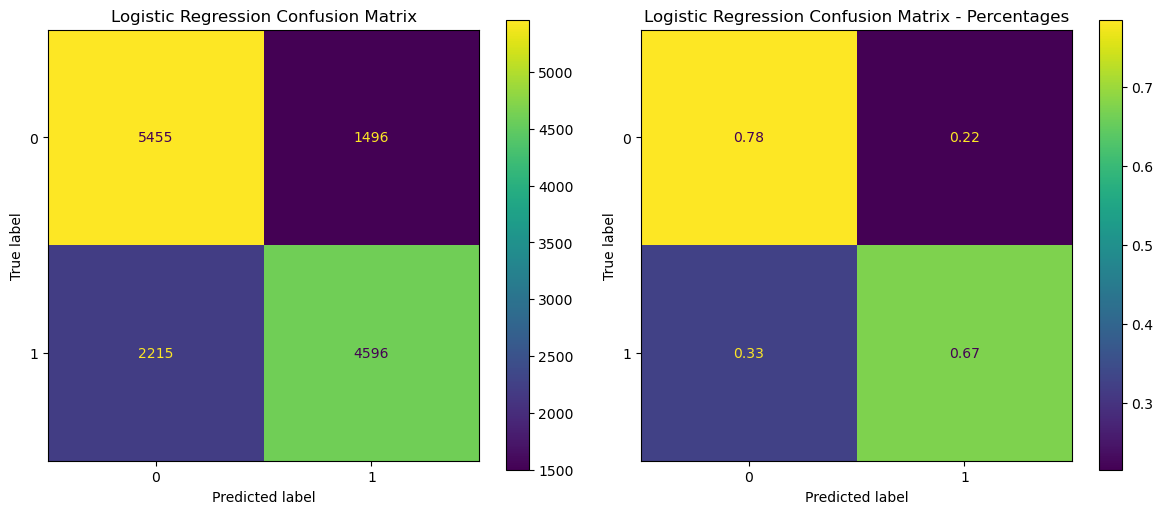

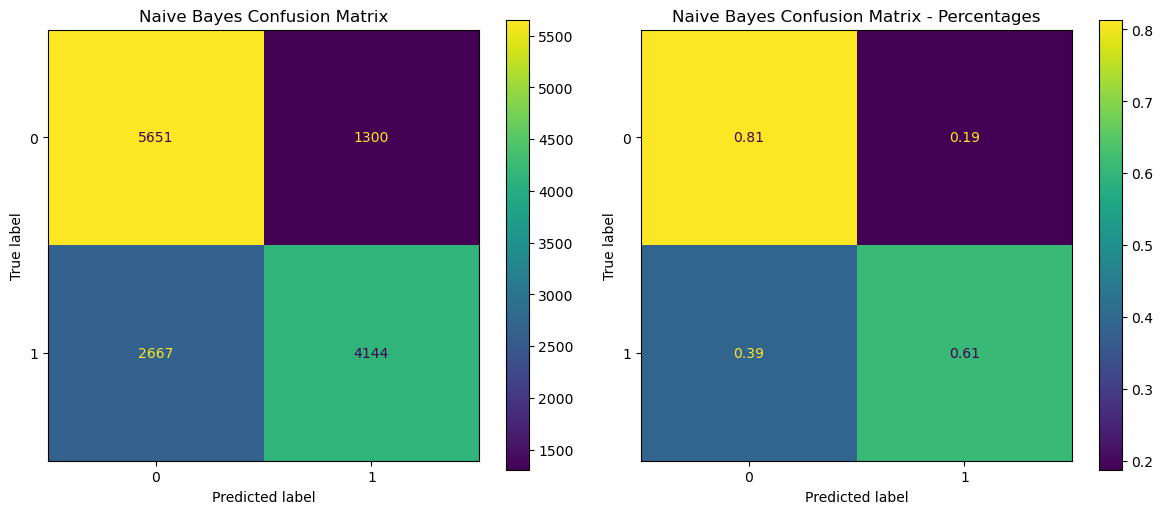

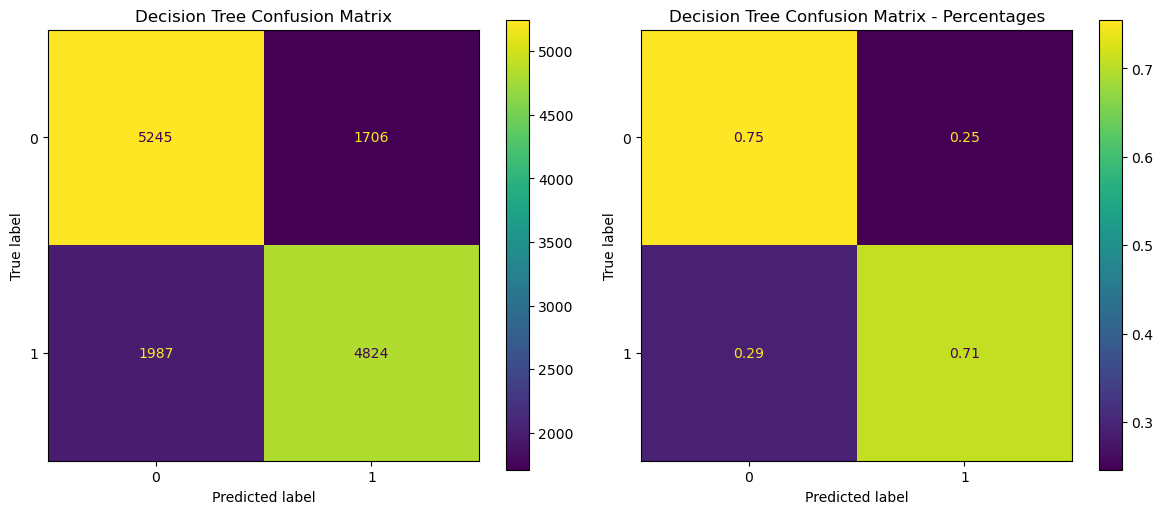

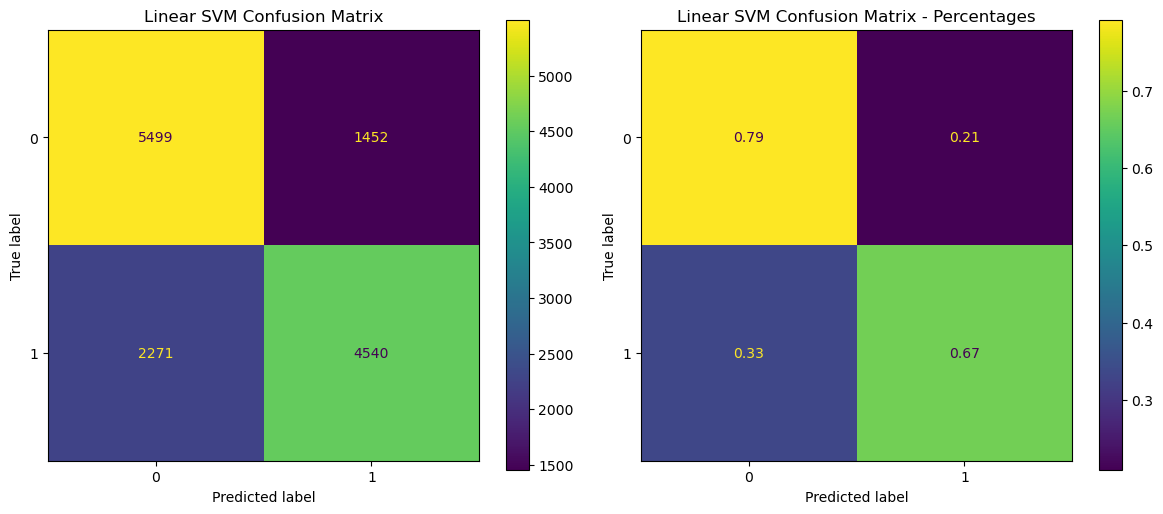

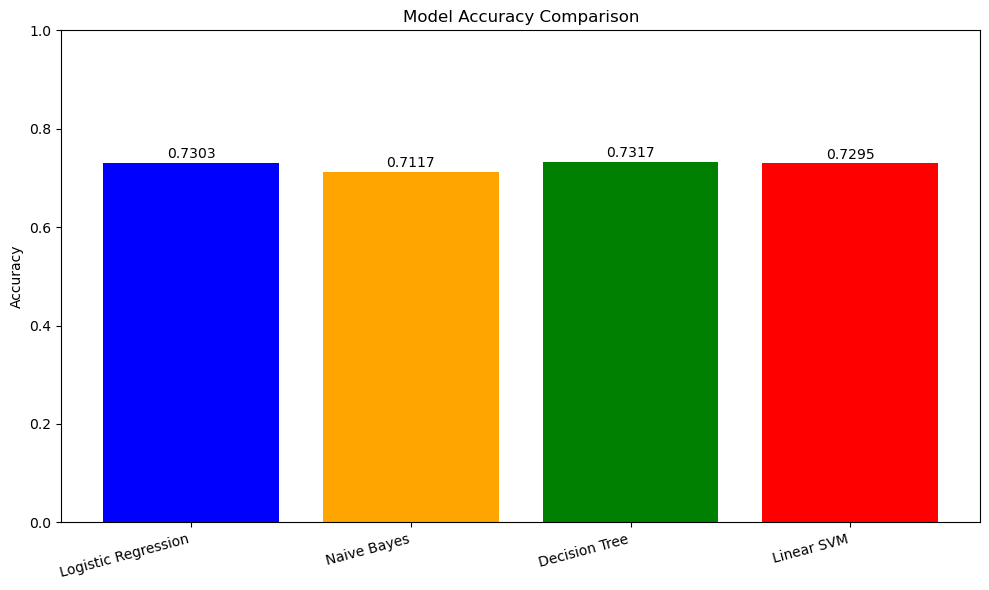

In [42]:
for model_name, model in models.items():
    predictions = model.predict(X_test)
    cm = confusion_matrix(y_test, predictions)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[0])
    axes[0].set_title(f"{model_name} Confusion Matrix")
    cm_perc = confusion_matrix(y_test, predictions, normalize="true")
    disp_perc = ConfusionMatrixDisplay(confusion_matrix=cm_perc, display_labels=model.classes_)
    disp_perc.plot(ax=axes[1])
    axes[1].set_title(f"{model_name} Confusion Matrix - Percentages")
    plt.tight_layout()
    plt.show()

# model comparison plot
model_names = list(models.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['blue', 'orange', 'green', 'red'])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha='center')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## 7. Check Overfitting

Analyze train vs test accuracy to detect overfitting

In [43]:
models_eval = [
    ("Logistic Regression", models['Logistic Regression']),
    ("Naive Bayes", models['Naive Bayes']),
    ("Linear SVM", models['Linear SVM'])
]
print("Overfitting Analysis (Test Accuracy - Train Accuracy):\n")
for model_name, model in models_eval:
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    diff = test_acc - train_acc
    print(f"{model_name}: {diff:.4f}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}\n")

Overfitting Analysis (Test Accuracy - Train Accuracy):

Logistic Regression: 0.0034
  Train Accuracy: 0.7269
  Test Accuracy:  0.7303

Naive Bayes: 0.0027
  Train Accuracy: 0.7091
  Test Accuracy:  0.7117

Linear SVM: 0.0039
  Train Accuracy: 0.7256
  Test Accuracy:  0.7295



## 8. Save Models

Persist trained models for later prediction

In [44]:
os.makedirs('models', exist_ok=True)
for model_name, model in models.items():
    filename = f"models/{model_name.replace(' ', '_').lower()}_model.pkl"
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

# save the scaler
scaler_path = "models/scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"Saved: {scaler_path}")

Saved: models/logistic_regression_model.pkl
Saved: models/naive_bayes_model.pkl
Saved: models/decision_tree_model.pkl
Saved: models/linear_svm_model.pkl
Saved: models/scaler.pkl
